In [1559]:
import numpy as np 
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

import statsmodels.formula.api as smf
import statsmodels.api as sm
from pandas.api.types import is_numeric_dtype

In [1560]:
products= pd.read_csv('products.csv')

In [1561]:
df=products.copy()

# 사전 처리

In [1562]:
df["first_review_date"] = pd.to_datetime(df["first_review_date"], errors="coerce")

# 기준일 고정
today = pd.Timestamp("2026-02-26")

df["age_days"] = (today - df["first_review_date"]).dt.days
df["age_days"] = df["age_days"].fillna(df["age_days"].median())

In [1563]:
# 기능성 컬럼 생성(값이 하나라도 입력돼 있으면 기능성으로 간주)
func_cols = ["is_whitening", "is_wrinkle_reduction", "is_sunscreen", "is_acne"]
missing = [c for c in func_cols if c not in df.columns]
if missing:
    raise KeyError(f"기능성 원천 컬럼이 없음: {missing}")

df["is_functional"] = df[func_cols].notna().any(axis=1).astype(int)

# 확인
print(df["is_functional"].value_counts(dropna=False))

is_functional
0    692
1    256
Name: count, dtype: int64


In [1564]:
stable = df[df["final_soft_landing"].astype(str) == "True"]
unstable = df[df["final_soft_landing"].astype(str) == "False"]

outcomes = [
    "likes","shares","review_count",
    "engagement_score","cp_index","review_density"
]

stable[outcomes].mean(), unstable[outcomes].mean()

(likes               4250.101266
 shares                69.487342
 review_count         825.943038
 engagement_score    1112.630063
 cp_index             427.043459
 review_density         1.254396
 dtype: float64,
 likes               2791.273723
 shares                43.147810
 review_count         328.620438
 engagement_score     612.376642
 cp_index             172.282261
 review_density         1.089600
 dtype: float64)

In [1565]:
df["price_rel"] = df["price"] - df.groupby("category_2")["price"].transform("mean")

df["log_price"] = np.log1p(df["price"])

# 안정형

In [1566]:
df_model = df[df["final_soft_landing"].notna()].copy()
df_model["y"] = df_model["final_soft_landing"].astype(int)

# 누수 변수(likes, shares, review_count, engagement_score, cp_index) 제거
# category_2 추가
formula2 = """
y ~ 
age_days +
is_functional +
log_price +
C(category_2)
"""

logit_model = smf.logit(formula2, data=df_model).fit()
print(logit_model.summary())

         Current function value: 0.247552
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  706
Model:                          Logit   Df Residuals:                      689
Method:                           MLE   Df Model:                           16
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                  0.5344
Time:                        19:03:23   Log-Likelihood:                -174.77
converged:                      False   LL-Null:                       -375.36
Covariance Type:            nonrobust   LLR p-value:                 2.065e-75
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -9.5072      3.345     -2.842      0.004     -16.063      -2.951
C(category_2)[T.남성메이

c:\Users\kyng0\OneDrive\Desktop\분석용 데이터셋\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [1567]:
# 연착륙 확률 예측
df_model["stability_prob"] = logit_model.predict(df_model)

df_model[["product_name","stability_prob"]].head()

,product_name,stability_prob
0,뉴트로지나 립모이스춰,0.870570
5,"오릭스 올데이 선크림 플러스 (SPF50+, PA+++)",0.673976
6,오릭스 립 에센스 10 ml 딸기 향,0.840450
7,과일나라 알로에베라 모이스처 아쿠아 수딩 젤 300 ml,0.772327
8,과일나라 알로에베라 모이스처 아쿠아 수딩 젤 150 g,0.755623


In [1568]:
# 퍼센타일 기반 점수화
df_model["stability_score"] = (
    df_model["stability_prob"].rank(pct=True) * 100
)

In [1569]:
df = df.merge(
    df_model[["product_code","stability_prob","stability_score"]],
    on="product_code",
    how="left"
)

In [1570]:
top10_stable_products = (
    df.sort_values("stability_score", ascending=False)
      [["product_code","product_name","brand","category_2","stability_score","stability_prob"]]
      .head(10)
)

top10_stable_products

,product_code,product_name,brand,category_2,stability_score,stability_prob
145,1043654,데일리콤마 오드 퍼퓸(나이브머스크) 30 ml,데일리콤마,남성향수,100.000000,1.000000
146,1043655,데일리콤마 오드 퍼퓸(반타우드) 30 ml,데일리콤마,남성향수,99.858357,1.000000
151,1043660,닥터지오 시카진정 올인원 밀크플루이드 150 ml,닥터지오,남성스킨케어,99.716714,0.929016
79,1035210,오릭스 엘레강스 올인원 스킨＆로션 410 ml,오릭스,남성스킨케어,99.575071,0.923646
166,1044964,어퓨 더퓨어 티트리 클렌징 폼 200ml,어퓨_더퓨어,클렌징/필링,99.433428,0.911800
211,1046784,초초스랩 클린톡스 산뜻 클렌징 밤 50 ml,초초스랩,클렌징/필링,99.291785,0.908971
109,1039941,포인트 딥클린 클렌징 오일 100ml,포인트,클렌징/필링,99.150142,0.906031
95,1038594,제이엠솔루션 B5 히아 모이스처라이징 클렌징 폼 150 ml,제이엠솔루션,클렌징/필링,99.008499,0.899113
89,1038219,식물원 병풀 클리어 클렌징 워터,식물원,클렌징/필링,98.866856,0.897773
77,1035082,딥 클렌징 폼 150 ml,다이소,클렌징/필링,98.725212,0.893762


# 공격형

In [1571]:
df["growth_target"] = np.log1p(df["engagement_score"])

In [1572]:
formula_growth = """
np.log1p(engagement_score) ~
age_days +
is_functional +
log_price +
C(category_2)
"""

ols_model = smf.ols(formula_growth, data=df).fit(cov_type="HC3")  # 이 줄 하나만 남기고
# ols_model = smf.ols(formula_growth, data=df).fit(cov_type="HC3")  # ← 이 줄 삭제
print(ols_model.summary())

                                OLS Regression Results                                
Dep. Variable:     np.log1p(engagement_score)   R-squared:                       0.399
Model:                                    OLS   Adj. R-squared:                  0.389
Method:                         Least Squares   F-statistic:                     32.01
Date:                        Wed, 04 Mar 2026   Prob (F-statistic):           1.79e-77
Time:                                19:03:23   Log-Likelihood:                -1300.2
No. Observations:                         948   AIC:                             2634.
Df Residuals:                             931   BIC:                             2717.
Df Model:                                  16                                         
Covariance Type:                          HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16320\1991132016.py:16: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16320\1991132016.py:16: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16320\1991132016.py:16: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16320\1991132016.py:16: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\kyng0\OneDrive\Desktop\분석용 데이터셋\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kyng0\OneDrive\Desktop\분석용

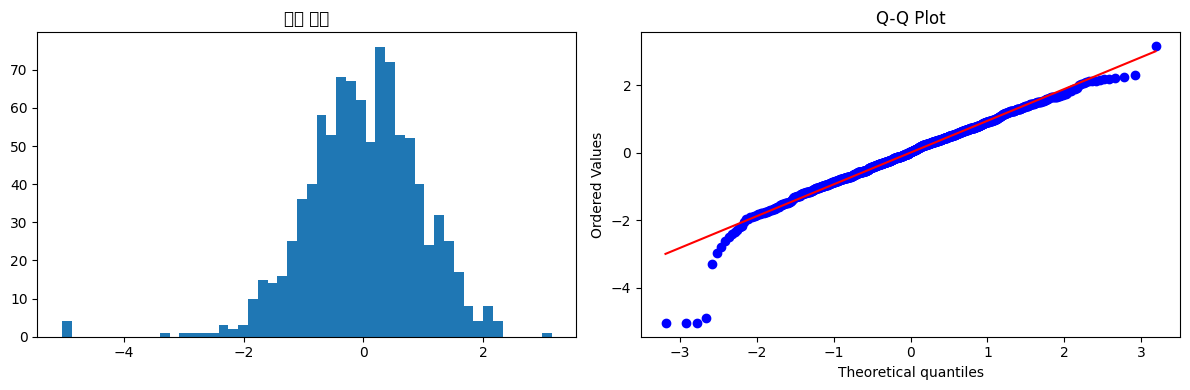

Skewness: -0.635
Kurtosis: 2.642


In [1573]:
# Cell 16 아래에 추가
import scipy.stats as stats

residuals = ols_model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 잔차 히스토그램
axes[0].hist(residuals, bins=50)
axes[0].set_title("잔차 분포")

# Q-Q plot
stats.probplot(residuals, plot=axes[1])
axes[1].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

print(f"Skewness: {residuals.skew():.3f}")
print(f"Kurtosis: {residuals.kurtosis():.3f}")

In [1574]:
# 🔥 1️⃣ 공격형 예측값 (log scale)
df["growth_pred_log"] = ols_model.predict(df)

df[["product_name","growth_pred_log"]].head()

,product_name,growth_pred_log
0,뉴트로지나 립모이스춰,5.421988
1,도루코TG2플러스5P,3.090256
2,메이크업 리무버티슈 60매,5.587300
3,오릭스 엘레강스 리프레싱 남성용 스킨 365ml,4.647861
4,오릭스 엘레강스 리프레싱 남성용 로션 365ml,4.647861


In [1575]:
df["growth_pred"] = np.expm1(df["growth_pred_log"])

In [1576]:
df["growth_score"] = (
    df["growth_pred_log"].rank(pct=True) * 100
)

In [1577]:
top10_growth_products = (
    df.sort_values("growth_score", ascending=False)
      [["product_code","product_name","brand","category_2","growth_score","growth_pred_log"]]
      .head(10)
)

top10_growth_products

,product_code,product_name,brand,category_2,growth_score,growth_pred_log
75,1035080,시카 카밍 토너 패드 100매입,다이소,팩/마스크,100.000000,7.961886
242,1049277,VT 시카 슬리핑 마스크 4 ml 6개입,VT,팩/마스크,99.894515,7.629141
243,1049285,VT 슈퍼 히알론 슬리핑 마스크 4 ml 6개입,VT,팩/마스크,99.789030,7.599335
376,1059840,소미썸 당근 카밍 패드 40매입,소미썸,팩/마스크,99.578059,7.450477
374,1059838,소미썸 가지 필링 토너 패드 50매입,소미썸,팩/마스크,99.578059,7.450477
373,1059837,소미썸 쌀뜬물 클렌징 워터 패드 50매입,소미썸,팩/마스크,99.578059,7.450477
375,1059839,소미썸 청귤 미백 토닝 패드 50매입,소미썸,팩/마스크,99.367089,7.424172
136,1042631,셀더마데일리 V핏 마스크 13 g,셀더마데일리,팩/마스크,99.261603,7.338387
301,1053494,메디필 엑스트라 슈퍼 9 플러스 피지 클리너 코 시트 30매입,메디필,팩/마스크,99.156118,7.185856
413,1060487,메디필 락토 모공 리프팅 랩핑 마스크 4 ml 4개입,메디필,팩/마스크,99.050633,7.153813


# 내부 브랜드 분석

In [1578]:
brand_stable_top10 = (
    brand_summary
        .sort_values("mean_stability", ascending=False)
        [["brand","n_products","mean_stability"]]
        .head(10)
)

brand_stable_top10

,brand,n_products,mean_stability
19,데일리콤마,6,99.929178
14,닥터지오,2,99.150142
79,팩미인,1,97.450425
9,뉴트로지나,1,96.458924
57,오릭스,9,93.889114
42,비알티씨,4,92.681775
10,다나한,6,90.481586
24,랩팩토리,2,90.226629
63,제이엠솔루션,7,89.376771
51,식물원,11,86.118980


In [1579]:
brand_growth_top10 = (
    brand_summary
        .sort_values("mean_growth", ascending=False)
        [["brand","n_products","mean_growth"]]
        .head(10)
)

brand_growth_top10

,brand,n_products,mean_growth
47,소미썸,6,99.314346
24,랩팩토리,2,95.385021
79,팩미인,1,94.936709
46,셀더마데일리,5,93.797468
10,다나한,6,90.550281
26,마데카21,9,87.728551
51,식물원,11,87.245876
13,닥터오라클,10,86.181435
43,비프루브,12,83.139944
36,바이 리얼베리어,5,82.869198


# 입점 희망 브랜드 예측 모델

In [1580]:
def grade_structure(score):
    if pd.isna(score):
        return "NA"
    if score >= 80:
        return "A (매우 우수)"
    elif score >= 70:
        return "B (우수)"
    elif score >= 60:
        return "C (보통 이상)"
    elif score >= 50:
        return "D (보완 필요)"
    else:
        return "E (재설계 필요)"

In [1581]:
def evaluate_new_brand(new_skus_df):

    tmp = new_skus_df.copy()
    tmp["is_functional"] = pd.to_numeric(tmp["is_functional"], errors="coerce").fillna(0).astype(int)
    tmp["log_price"] = np.log1p(tmp["price"])

    # 신규 브랜드 기본값 세팅
    tmp["age_days"] = df["age_days"].median()

    # ✅ logit 확률 예측
    tmp["stability_prob"] = logit_model.predict(tmp)

    # ✅ 내부 제품 stability_prob 분포 기준으로 백분위 변환
    # (단순 *100이 아니라, 내부 분포에서 몇 %에 위치하는지)
    internal_probs = df_model["stability_prob"]  # 내부 제품들의 확률값
    tmp["pred_stability"] = tmp["stability_prob"].apply(
        lambda p: float((internal_probs < p).mean() * 100)
    )

    # ✅ ols 예측
    tmp["growth_pred_log"] = ols_model.predict(tmp)
    internal_growth = df["growth_pred_log"]
    tmp["pred_growth"] = tmp["growth_pred_log"].apply(
        lambda g: float((internal_growth < g).mean() * 100)
    )

    # 브랜드 평균
    brand_stability = float(tmp["pred_stability"].mean())
    brand_growth = float(tmp["pred_growth"].mean())

    # 기존 브랜드 분포 기준 백분위
    bs = pd.to_numeric(brand_summary_valid["mean_stability"], errors="coerce").dropna()
    bg = pd.to_numeric(brand_summary_valid["mean_growth"], errors="coerce").dropna()

    stab_percentile = float((bs < brand_stability).mean() * 100) if len(bs) else np.nan
    grow_percentile = float((bg < brand_growth).mean() * 100) if len(bg) else np.nan

    # 0~100 정규화
    brand_stability_norm = (brand_stability - bs.min()) / (bs.max() - bs.min()) * 100 if len(bs) else np.nan
    brand_growth_norm = (brand_growth - bg.min()) / (bg.max() - bg.min()) * 100 if len(bg) else np.nan

    return {
        "예측 안정형 점수(원점수)": round(brand_stability, 2),
        "예측 안정형 점수(0-100 정규화)": round(float(brand_stability_norm), 1),
        "안정형 백분위": round(stab_percentile, 1),
        "안정형 등급": grade_structure(stab_percentile),
        "예측 공격형 점수(원점수)": round(brand_growth, 2),
        "예측 공격형 점수(0-100 정규화)": round(float(brand_growth_norm), 1),
        "공격형 백분위": round(grow_percentile, 1),
        "공격형 등급": grade_structure(grow_percentile),
    }

In [1582]:
brand_summary = (
    df.groupby("brand")
      .agg(
          n_products=("product_code","nunique"),
          mean_stability=("stability_score","mean"),
          mean_growth=("growth_score","mean")
      )
      .reset_index()
)

brand_summary_valid = brand_summary[brand_summary["n_products"] >= 5] 

In [1583]:
new_brand = pd.DataFrame({
    "category_2": ["기초스킨케어","립케어"],
    "is_functional": [1, 0],
    "price" : [5000, 3000]
})

evaluate_new_brand(new_brand)



{'예측 안정형 점수(원점수)': 61.76,
 '예측 안정형 점수(0-100 정규화)': 59.8,
 '안정형 백분위': 64.5,
 '안정형 등급': 'C (보통 이상)',
 '예측 공격형 점수(원점수)': 47.47,
 '예측 공격형 점수(0-100 정규화)': 47.2,
 '공격형 백분위': 37.9,
 '공격형 등급': 'E (재설계 필요)'}

In [1584]:
df_score = df[['product_code','stability_score','growth_score']]

In [1585]:
df_score.isna().sum()

product_code         0
stability_score    242
growth_score         0
dtype: int64

In [1586]:
tableau_i = pd.read_csv('tableau_ingredients.csv',encoding='utf-8')
tableau_r = pd.read_csv('tableau_products_reviews.csv',encoding='utf-8')
tableau_s = pd.read_csv('tableau_search.csv',encoding='utf-8')




C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16320\3317839496.py:1: DtypeWarning: Columns (0: is_allergic) have mixed types. Specify dtype option on import or set low_memory=False.
  tableau_i = pd.read_csv('tableau_ingredients.csv',encoding='utf-8')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16320\3317839496.py:2: DtypeWarning: Columns (0: allergic_group, 1: ITEM_PH, 2: ph_category, 3: is_whitening, 4: is_wrinkle_reduction, 5: is_sunscreen, 6: is_acne, 7: is_soft_landing_dtw, 8: is_soft_landing_surv, 9: is_soft_landing_rule, 10: is_soft_landing_ml, 11: final_soft_landing, 12: is_reorder, 13: is_ambiguous, 14: start_date, 15: end_date, 16: description, 17: event_type) have mixed types. Specify dtype option on import or set low_memory=False.
  tableau_r = pd.read_csv('tableau_products_reviews.csv',encoding='utf-8')


In [1587]:
dfi = pd.merge(tableau_i,df_score,on='product_code',how='left')
dfr = pd.merge(tableau_r,df_score,on='product_code',how='left')
dfs = pd.merge(tableau_s,df_score,on='product_code',how='left')

In [1588]:
# dfi.to_csv('tableau_ingredients_score.csv',encoding='utf-8')
# dfr.to_csv('tableau_products_reviews_score.csv',encoding='utf-8')
# dfs.to_csv('tableau_search_score.csv',encoding='utf-8')